In [10]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import yfinance as yf

In [35]:
tickers = ["^GSPC", "F", "MSFT", "ORCL", "^IRX"]
data = yf.download(tickers, interval="1mo", start="2002-01-01", end="2018-12-31", auto_adjust=False)["Close"]
data.columns = data.columns.get_level_values(0)
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,F,MSFT,ORCL,^GSPC,^IRX
Date,,,,,
2002-01-01,15.30,31.855000,17.260000,1130.199951,1.720
2002-02-01,14.88,29.170000,16.620001,1106.729980,1.720
2002-03-01,16.49,30.155001,12.800000,1147.390015,1.740
2002-04-01,16.00,26.129999,10.040000,1076.920044,1.730
2002-05-01,17.65,25.455000,7.920000,1067.140015,1.705


In [36]:
def LogDiff(x):
    x_diff = 100 * np.log(x/x.shift(1))
    x_diff = x_diff.dropna()
    return x_diff

In [38]:
data = pd.DataFrame({
    "USTB3M": data["^IRX"]/12,
    "ret_sandp": LogDiff(data["^GSPC"]),
    "ret_ford": LogDiff(data["F"]),
    "ersandp": LogDiff(data["^GSPC"]) - data["^IRX"] / 12,
    "erford": LogDiff(data["F"]) - data["^IRX"] / 12
})

In [39]:
data.head()

,USTB3M,ret_sandp,ret_ford,ersandp,erford
Date,,,,,
2002-01-01,0.143333,NaN,NaN,NaN,NaN
2002-02-01,0.143333,-2.098486,-2.783480,-2.241819,-2.926814
2002-03-01,0.145000,3.608011,10.273609,3.463011,10.128609
2002-04-01,0.144167,-6.338465,-3.016540,-6.482632,-3.160707
2002-05-01,0.142083,-0.912297,9.814704,-1.054380,9.672621


In [33]:
# data = data.dropna()

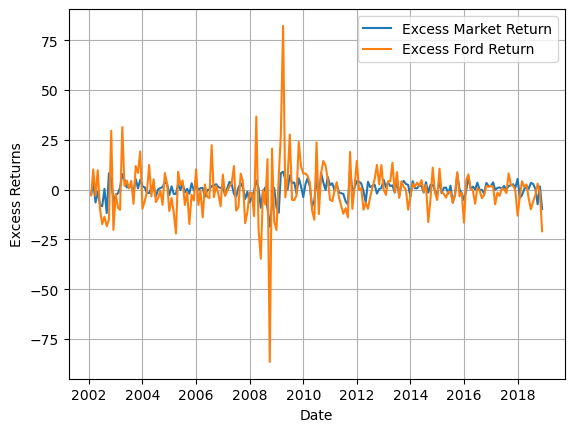

In [40]:
plt.figure(1)
plt.plot(data["ersandp"], label="Excess Market Return")
plt.plot(data["erford"], label="Excess Ford Return")

plt.xlabel("Date")
plt.ylabel("Excess Returns")
plt.grid(True)

plt.legend()
plt.show()

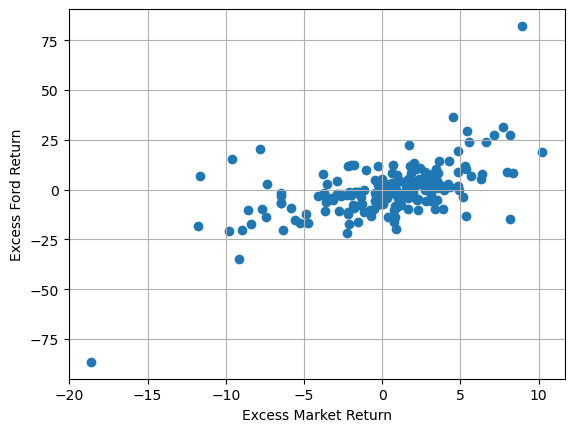

In [42]:
plt.figure(2)
plt.scatter(data["ersandp"], data["erford"])
plt.xlabel("Excess Market Return")
plt.ylabel("Excess Ford Return")
plt.grid(True)
plt.show()

In [44]:
formula = "erford ~ ersandp"
results = smf.ols(formula, data).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 erford   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     98.43
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           3.90e-19
Time:                        14:34:05   Log-Likelihood:                -771.31
No. Observations:                 203   AIC:                             1547.
Df Residuals:                     201   BIC:                             1553.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9779      0.764     -1.279      0.2

The intercept is not statistically significant to reject the null that alpha differenct from 0,so ford does not significantly out-perform or underperform the overall market

In [46]:
# F-test
f_test = results.f_test(hypothesis)
print(f_test)

<F test: F=20.62148399252659, p=9.634820517193945e-06, df_denom=201, df_num=1>


Checking if the population marrket coef is 1,\
we reject the null in this case